# Annealing turns normalization into a path problem

Annealed importance sampling estimates a partition-function ratio by transporting samples through a sequence of intermediate inverse temperatures. It is not itself an FPRAS guarantee, but it makes the role of annealing schedules and weight degeneracy concrete.

In [1]:
CHAPTER_DIR = "ch08"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## AIS on a small Ising model

exact Z 5345.049277841634


,temperatures,Z estimate,relative error,weight ESS
0,3,4821.196088,-0.098007,155.957801
1,6,5496.065327,0.028253,200.624189
2,12,5071.292736,-0.051217,332.199675
3,24,5465.694464,0.022571,382.989878


Saved: figs/ch08_04_ais_schedule.pdf


Saved: figs/ch08_04_ais_schedule.png


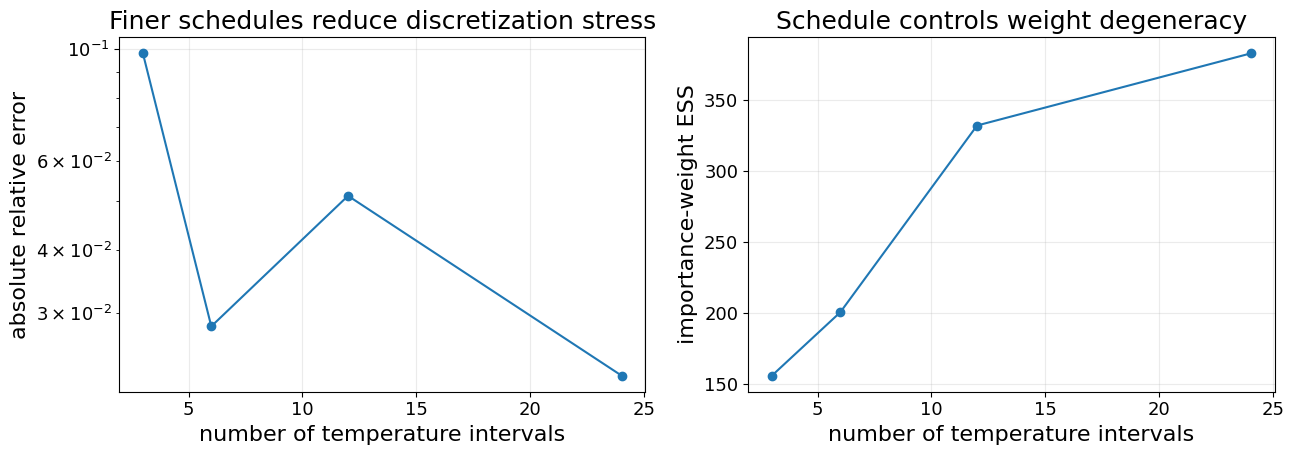

In [2]:
from itertools import product
n=10; edges=[(i,(i+1)%n) for i in range(n)]; J=.55; h=.12
states=np.array(list(product([-1,1],repeat=n)))
def energy_score(x): return J*sum(x[i]*x[j] for i,j in edges)+h*x.sum()
scores=np.array([energy_score(x) for x in states]); Z_exact=np.exp(scores).sum(); print('exact Z',Z_exact)
def mh_sweep(x,beta):
    for _ in range(n):
        i=RNG.integers(n); y=x.copy(); y[i]*=-1; a=min(1.,np.exp(beta*(energy_score(y)-energy_score(x))));
        if RNG.random()<a: x=y
    return x
def ais(K=30,N=500):
    betas=np.linspace(0,1,K+1); logw=[]
    for _ in range(N):
        x=RNG.choice([-1,1],size=n); lw=0.
        for k in range(1,len(betas)):
            lw+=(betas[k]-betas[k-1])*energy_score(x); x=mh_sweep(x,betas[k])
        logw.append(lw)
    logw=np.asarray(logw); m=logw.max(); estimate=(2**n)*np.exp(m)*np.mean(np.exp(logw-m)); ess=(np.exp(logw-m).sum()**2)/np.exp(2*(logw-m)).sum(); return estimate,ess,logw
rows=[]
for K in [3,6,12,24]:
    est,ess,lw=ais(K); rows.append((K,est,est/Z_exact-1,ess))
df=pd.DataFrame(rows,columns=['temperatures','Z estimate','relative error','weight ESS']); display(df)
fig,axes=plt.subplots(1,2,figsize=(13.2,4.8)); axes[0].plot(df.temperatures,np.abs(df['relative error']),marker='o'); axes[0].set_yscale('log'); axes[0].set_xlabel('number of temperature intervals'); axes[0].set_ylabel('absolute relative error'); axes[0].set_title('Finer schedules reduce discretization stress'); axes[0].grid(alpha=.25)
axes[1].plot(df.temperatures,df['weight ESS'],marker='o'); axes[1].set_xlabel('number of temperature intervals'); axes[1].set_ylabel('importance-weight ESS'); axes[1].set_title('Schedule controls weight degeneracy'); axes[1].grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch08_04_ais_schedule'); plt.show()

## Exercises

1. Compare linear and nonlinear temperature schedules.
2. Increase the number of transition sweeps at every temperature.
3. Relate the variance of the AIS weights to overlap between neighboring distributions.
4. Explain which additional complexity bounds would be needed to turn this computational scheme into an FPRAS theorem.